# Code_Aster meshes: `.mail`

A `.mail` file is [Code_Aster](https://code-aster.org)'s own ASCII mesh: the one `LIRE_MAILLAGE(FORMAT='ASTER')` reads and Salome-Meca writes. meshio++ reads and writes it in both engines (the C++ core and the Python reference), so **`.mail` ↔ `.med` / `.vtu` / any meshio++ format** needs no Code_Aster installation.

A file is a sequence of blocks, each opened by a keyword and closed by `FINSF`. `COOR_3D` holds the named nodes, element keywords (`HEXA20`, `QUAD8`, …) hold the elements, and `GROUP_MA`/`GROUP_NO` hold named element and node groups, which become meshio++ regions.

The files used here are in `tests/python/meshes/code_aster/`. `tools/gen_code_aster_fixtures.py` writes them in Code_Aster's own node numbering, laid out the way Code_Aster's own writer lays a file out.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the writer's warnings about renamed groups and dropped data are shown as text below.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MAIL = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes', 'code_aster')
TMP = tempfile.mkdtemp()


def path(name):
    return os.path.join(MAIL, name + '.mail')


def to_grid(mesh, cell_data=None, point_data=None):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4')]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460)):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=True, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector((-1.0, -1.4, 0.45), viewup=(0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(1.0)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Reading a `.mail`

`hexa20_block.mail` is two `HEXA20` bricks and a `QUAD8` face, with three groups. Two of them share the name `X0`: one is the face (a `GROUP_MA`), the other its four corner nodes (a `GROUP_NO`). They become two regions, one per kind. Groups have no number in a `.mail` file, so the regions carry no tag.

In [2]:
block = mp.read(path('hexa20_block'))
print(block)
print()
for r in block.regions:
    print(f'{r.kind:5s} {r.name:7s} dim {r.dim:2d}  entries {r.entries.tolist()}')

<meshio++ mesh object>
  Number of points: 32
  Number of cells:
    hexahedron20: 2
    quad8: 1
  Point sets: X0
  Cell sets: VOLUME, X0

point X0      dim -1  entries [0, 3, 4, 7]
cell  VOLUME  dim  3  entries [0, 1]
cell  X0      dim  2  entries [2]


## Every element keyword

`all_elements.mail` holds one element of each of the twenty keywords meshio++ reads, from `POI1` to `HEXA27`. `TRIA7` is a triangle with a centre node, and it needed a new cell type, `triangle7` (v16.0.0). Below, the surfaces and solids are coloured by block, and the `hexa20_block` bricks are shown with their `X0` node group highlighted.

['vertex', 'line', 'line3', 'line4', 'triangle', 'triangle6', 'triangle7', 'quad', 'quad8', 'quad9', 'tetra', 'tetra10', 'wedge', 'wedge15', 'wedge18', 'pyramid', 'pyramid13', 'hexahedron', 'hexahedron20', 'hexahedron27']


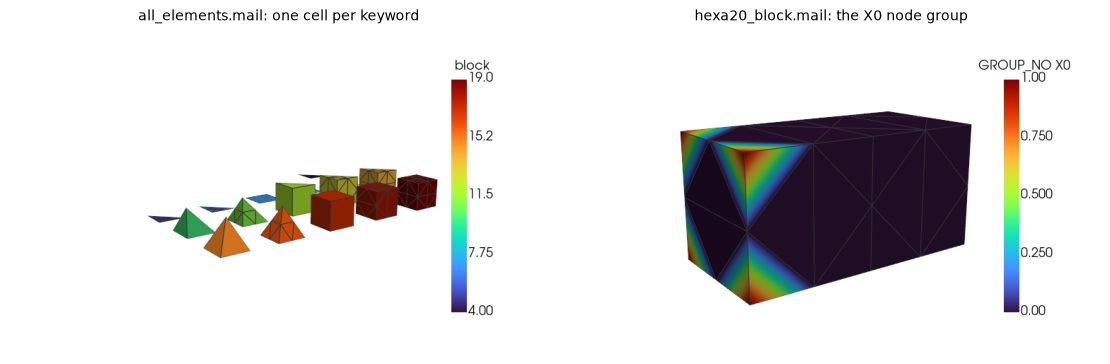

In [3]:
every = mp.read(path('all_elements'))
print([c.type for c in every.cells])
# The fixture strings the elements along x, each on its own nodes; lay them out on a
# 5 x 4 grid for the picture.
grid_points = every.points.copy()
for i, c in enumerate(every.cells):
    nodes = np.unique(c.data)
    grid_points[nodes, 0] -= 2.0 * i - 2.0 * (i % 5)
    grid_points[nodes, 1] -= 2.0 * (i // 5)
laid_out = mp.Mesh(grid_points, every.cells)
block_index = {'block': [np.full(len(c.data), i, dtype=float) for i, c in enumerate(every.cells)]}
x0 = np.zeros(len(block.points))
x0[[r for r in block.regions if r.kind == 'point' and r.name == 'X0'][0].entries] = 1.0
gallery([
    (to_grid(laid_out, cell_data=block_index), 'block', 'all_elements.mail: one cell per keyword', None),
    (to_grid(block, point_data={'GROUP_NO X0': x0}), 'GROUP_NO X0', 'hexa20_block.mail: the X0 node group', (0, 1)),
])

## The node order is Code_Aster's, not MED's

Code_Aster numbers the nodes of a quadratic hexahedron as the bottom-ring mid-edges, then the **vertical** mid-edges, then the top ring. VTK, and so meshio++, puts the verticals last. MED, although it comes from the same code, uses a third order: Code_Aster's own MED reader permutes every 3-D element. meshio++ keeps all of these in one [node-ordering registry](../../doc/node_ordering.md). The check below reads the bricks and confirms that every mid-edge node sits on the midpoint of its meshio++ edge.

In [4]:
from meshioplusplus._node_order import node_order

print('code_aster hexahedron20, file slot of each meshio++ node:', list(node_order('code_aster', 'hexahedron20').to_meshio))
print('med        hexahedron20, file slot of each meshio++ node:', list(node_order('med', 'hexahedron20').to_meshio))

edges = [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4), (0, 4), (1, 5), (2, 6), (3, 7)]
worst = 0.0
for row in block.cells_dict['hexahedron20']:
    x = block.points[row]
    worst = max(worst, max(np.abs(x[8 + k] - (x[a] + x[b]) / 2).max() for k, (a, b) in enumerate(edges)))
print('largest mid-edge offset from its edge midpoint:', worst)

code_aster hexahedron20, file slot of each meshio++ node: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 16, 17, 18, 19, 12, 13, 14, 15]
med        hexahedron20, file slot of each meshio++ node: [4, 5, 6, 7, 0, 1, 2, 3, 12, 13, 14, 15, 8, 9, 10, 11, 16, 17, 18, 19]
largest mid-edge offset from its edge midpoint: 0.0


## Through MED and back

MED is how a mesh reaches Salome, and `.mail` is how it reaches an older Code_Aster study. A `.mail` written by meshio++, converted to `.med` and back, keeps its connectivity and groups line for line. The MED reader adds its family arrays (`point_tags`/`cell_tags`), which have no `.mail` equivalent; the writer drops them with a warning.

In [5]:
first = os.path.join(TMP, 'first.mail')
mp.write(first, block)
mp.write(os.path.join(TMP, 'block.med'), block)
via_med = mp.read(os.path.join(TMP, 'block.med'))
print('from MED:', [c.type for c in via_med.cells], sorted({(r.kind, r.name) for r in via_med.regions}))
via_med.point_data.clear()
via_med.cell_data.clear()
second = os.path.join(TMP, 'second.mail')
mp.write(second, via_med)


def body(p):
    return [line for line in open(p).read().splitlines() if not line.startswith('%')]


print('identical after .mail -> .med -> .mail:', body(first) == body(second))

from MED: ['hexahedron20', 'quad8'] [('cell', 'VOLUME'), ('cell', 'X0'), ('point', 'X0')]
identical after .mail -> .med -> .mail: True


## What the writer emits

Nodes become `N1…` and elements `M1…`. Every line stays within the 80 columns Code_Aster reads, so a long record continues on an indented line. Group names are cut to Code_Aster's 24 characters of letters, digits and `_`, and a name that then collides gets a numbered suffix. Side regions and data arrays have no `.mail` equivalent; they are dropped with a warning and a provenance note at the top of the file.

In [6]:
demo = mp.Mesh(block.points, block.cells, regions=[
    mp.Region('clamped face (x = 0)', 'cell', [2]),
    mp.Region('clamped face (x = 0), nodes', 'point', block.regions[0].entries),
])
out = os.path.join(TMP, 'demo.mail')
mp.write(out, demo)
text = open(out).read()
lines = text.splitlines()
print('longest line:', max(len(line) for line in lines), 'columns')
print('\n'.join(line for line in lines if not line.startswith('%'))[-600:])

longest line: 78 columns
0000000000000E+00 1.0000000000000000E+00 5.0000000000000000E-01
N30 1.5000000000000000E+00 0.0000000000000000E+00 1.0000000000000000E+00
N31 2.0000000000000000E+00 5.0000000000000000E-01 1.0000000000000000E+00
N32 1.5000000000000000E+00 1.0000000000000000E+00 1.0000000000000000E+00
FINSF
HEXA20
M1 N1 N2 N3 N4 N5 N6 N7 N8 N9 N10 N11 N12 N13 N14 N15 N16 N17 N18 N19 N20
M2 N2 N21 N22 N3 N6 N23 N24 N7 N25 N26 N27 N10 N14 N28 N29 N15 N30 N31 N32 N18
FINSF
QUAD8
M3 N1 N4 N8 N5 N12 N16 N20 N13
FINSF
GROUP_NO NOM=clamped_face__x___0___no
N1 N4 N5 N8
FINSF
GROUP_MA NOM=clamped_face__x___0_
M3
FINSF
FIN


## Onward

The same conversions are one command away from either CLI:

```sh
meshioplusplus convert study.mail study.med      # to Salome
meshioplusplus convert model.msh model.mail      # gmsh to Code_Aster
meshioplusplus info study.mail
```

The syntax subset, the node-order tables and what is dropped on write are spelled out in the [Code_Aster format page](../../doc/formats/code_aster.md).